# Sonar Tracker Evaluation — YOLOv26s + Bot-Sort/ByteTrack

Runs the YOLOv26s model on all sonar MOT sequences, compares predictions to GT,
and reports standard MOT metrics **separately for each class**.

**Model:** `net_fish_sonar_improved_fix/yolov26s_sonar_improved_c/weights/best.pt`  
**Classes:** fish (class_id = 1) · net (class_id = 2)  
**Metric matching:** IoU ≥ 0.5  

Sonar perspective: top-down, ROV at bottom of image.  
Physical coordinates (metres) are used in spatial error plots.

Run from `tracking/` directory.

In [1]:
print("Jupyter OK!")

Jupyter OK!


In [2]:
import sys
sys.path.insert(0, "..")

import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from tracking.utils.mot_metrics import (
    load_gt, run_inference, img_dir_for, frame_map,
    collect_images,
    compute_metrics, compute_hota, format_summary, build_summary_table,
    plot_metrics_bar, plot_error_breakdown,
    plot_track_comparison, plot_det_timeline, plot_id_switches,
)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

# ── Sonar physical mapping ─────────────────────────────────────────────────────
S_W, S_H  = 1200, 700
S_YMAX_M  = 8.0
S_XSPAN_M = S_YMAX_M * np.sin(np.deg2rad(45.0))

def sonar_px_to_m(cx, cy):
    y_m = (S_H - 1 - cy) * (S_YMAX_M / (S_H - 1))
    x_m = cx * (2 * S_XSPAN_M / S_W) - S_XSPAN_M
    return x_m, y_m, np.sqrt(x_m**2 + y_m**2)


/workspace/aquaculture-perception/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
REPO       = Path("..").resolve()
SONAR_ROOT = REPO / "data-processing" / "sonar" / "MOT"
MODEL_PATH = REPO / "runs/detect/outputs/training/net_fish_sonar_improved_fix/yolov26s_sonar_improved_c/weights/best.pt"

# ── Sequence selection ─────────────────────────────────────────────────────────
# List specific sequence names to process, or leave empty to run all.
SELECTED_SEQUENCES = [
    "2024-08-20_14-31-29",
    "2024-08-20_17-02-00",
    "2024-08-20_17-14-36",
    # "2024-08-20_17-39-32",
    "2024-08-20_17-55-40",
]

CONF       = 0.25
IOU_NMS    = 0.45
IOU_MATCH  = 0.5
DEVICE     = "cuda:0"
FRAME_RATE = 30
TRACKER    = "bytetrack"   # "bytetrack" | "botsort"

# ── Run identifier (used in filenames and titles) ────────────────────────────
MODEL_NAME = MODEL_PATH.parent.parent.name
RUN_TAG    = f"{MODEL_NAME}+{TRACKER}"

# ── MOT output ────────────────────────────────────────────────────────────────
MOT_OUTPUT_DIR = Path("outputs/inference_annotation_MOT11")
MOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

all_seqs = sorted([p.name for p in SONAR_ROOT.iterdir() if p.is_dir()])
SEQUENCES = [s for s in all_seqs if s in SELECTED_SEQUENCES] if SELECTED_SEQUENCES else all_seqs

print(f"Model   : {MODEL_PATH.name}")
print(f"Device  : {DEVICE}")
print(f"Tracker : {TRACKER}")
print(f"Sequences ({len(SEQUENCES)}):")
for s in SEQUENCES:
    print(f"  {s}")


Model   : best.pt
Device  : cuda:0
Tracker : bytetrack
Sequences (4):
  2024-08-20_14-31-29
  2024-08-20_17-02-00
  2024-08-20_17-14-36
  2024-08-20_17-55-40


## 1  Run inference on selected sequences
Edit `SELECTED_SEQUENCES` in the cell above to choose which sequences to process.  
Results are cached in memory and saved as MOT .txt files under `outputs/inference_annotation_MOT11/`.  
Re-run this cell to refresh.

In [4]:
gt_all   = {}  # full GT (all classes)
pred_all = {}  # full predictions
total_frames = {}

for seq in SEQUENCES:
    seq_path = SONAR_ROOT / seq
    idir     = img_dir_for(seq_path, "sonar")

    gt   = load_gt(seq_path / "gt" / "gt.txt", idir)   # all classes
    pred = run_inference(MODEL_PATH, idir,
                         conf=CONF, iou=IOU_NMS,
                         device=DEVICE, frame_rate=FRAME_RATE,
                         tracker_type=TRACKER,
                         desc=seq)

    gt_all[seq]   = gt
    pred_all[seq] = pred
    total_frames[seq] = len(list(idir.glob("*.jpg")))

    # ── Write MOT .txt (same format as tracking-inference_improved_MOT11.py) ──
    mot_lines = [
        f"{int(row.frame_id)},{int(row.track_id)},"
        f"{row.x:.2f},{row.y:.2f},{row.w:.2f},{row.h:.2f},"
        f"1,{int(row.class_id)},1.000000"
        for row in pred.sort_values(["frame_id", "track_id"]).itertuples()
    ] if not pred.empty else []
    mot_path = MOT_OUTPUT_DIR / f"INFERENCE_MOT11_SONAR_{seq}_{RUN_TAG}.txt"
    mot_path.write_text("\n".join(mot_lines), encoding="utf-8")

    for cls, name in [(1, "fish"), (2, "net")]:
        ng  = (gt["class_id"] == cls).sum()
        np_ = (pred["class_id"] == cls).sum() if not pred.empty else 0
        print(f"  {seq}  {name}: GT={ng}  Pred={np_}")
    print(f"  -> {mot_path.name}")


2024-08-20_14-31-29: 100%|██████████| 1060/1060 [00:41<00:00, 25.55it/s]


  2024-08-20_14-31-29  fish: GT=946  Pred=613
  2024-08-20_14-31-29  net: GT=1060  Pred=1051
  -> INFERENCE_MOT11_SONAR_2024-08-20_14-31-29_yolov26s_sonar_improved_c+bytetrack.txt


2024-08-20_17-02-00: 100%|██████████| 860/860 [00:33<00:00, 25.86it/s]


  2024-08-20_17-02-00  fish: GT=442  Pred=330
  2024-08-20_17-02-00  net: GT=860  Pred=851
  -> INFERENCE_MOT11_SONAR_2024-08-20_17-02-00_yolov26s_sonar_improved_c+bytetrack.txt


2024-08-20_17-14-36: 100%|██████████| 673/673 [00:25<00:00, 26.09it/s]


  2024-08-20_17-14-36  fish: GT=457  Pred=440
  2024-08-20_17-14-36  net: GT=673  Pred=672
  -> INFERENCE_MOT11_SONAR_2024-08-20_17-14-36_yolov26s_sonar_improved_c+bytetrack.txt


2024-08-20_17-55-40: 100%|██████████| 781/781 [00:27<00:00, 28.47it/s]

  2024-08-20_17-55-40  fish: GT=780  Pred=468
  2024-08-20_17-55-40  net: GT=781  Pred=783
  -> INFERENCE_MOT11_SONAR_2024-08-20_17-55-40_yolov26s_sonar_improved_c+bytetrack.txt


## 2  Compute metrics — fish (class 1)

In [5]:
gt_fish   = {s: gt_all[s][gt_all[s]["class_id"] == 1].copy() for s in SEQUENCES}
pred_fish = {s: pred_all[s][pred_all[s]["class_id"] == 1].copy()
             if not pred_all[s].empty else pred_all[s] for s in SEQUENCES}

accs_fish    = {}
results_fish = {}

for seq in SEQUENCES:
    acc, summary = compute_metrics(gt_fish[seq], pred_fish[seq], iou_threshold=IOU_MATCH)
    hota         = compute_hota(gt_fish[seq], pred_fish[seq])
    for k, v in hota.items():
        summary[k] = v
    accs_fish[seq]    = acc
    results_fish[seq] = summary
    print(f"{seq[-8:]}  "
          f"HOTA={hota['hota']*100:.1f}%  "
          f"MOTA={float(summary['mota'].iloc[0])*100:.1f}%  "
          f"IDF1={float(summary['idf1'].iloc[0])*100:.1f}%  "
          f"IDSW={int(summary['num_switches'].iloc[0])}")

print(f"\n── Fish metrics  [{RUN_TAG}] ──")
display(build_summary_table(results_fish))


14-31-29  HOTA=55.7%  MOTA=63.0%  IDF1=74.8%  IDSW=15
17-02-00  HOTA=55.9%  MOTA=63.3%  IDF1=70.5%  IDSW=14
17-14-36  HOTA=74.1%  MOTA=89.9%  IDF1=91.0%  IDSW=3
17-55-40  HOTA=52.4%  MOTA=55.4%  IDF1=69.1%  IDSW=8

── Fish metrics  [yolov26s_sonar_improved_c+bytetrack] ──


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,55.7%,42.8%,86.1%,63.0%,74.8%,3.9%,64.7%,99.8%,1,334,15,4,4,30
1,17-02-00,55.9%,47.8%,73.6%,63.3%,70.5%,7.4%,70.6%,94.5%,18,130,14,4,0,11
2,17-14-36,74.1%,72.4%,87.2%,89.9%,91.0%,2.1%,93.4%,97.0%,13,30,3,13,1,14
3,17-55-40,52.4%,37.5%,81.5%,55.4%,69.1%,4.5%,58.2%,97.0%,14,326,8,8,4,24


## 3  Compute metrics — net (class 2)

In [6]:
gt_net   = {s: gt_all[s][gt_all[s]["class_id"] == 2].copy() for s in SEQUENCES}
pred_net = {s: pred_all[s][pred_all[s]["class_id"] == 2].copy()
            if not pred_all[s].empty else pred_all[s] for s in SEQUENCES}

accs_net    = {}
results_net = {}

for seq in SEQUENCES:
    if gt_net[seq].empty:
        print(f"{seq[-8:]}: no net GT — skipping")
        continue
    acc, summary = compute_metrics(gt_net[seq], pred_net[seq], iou_threshold=IOU_MATCH)
    hota         = compute_hota(gt_net[seq], pred_net[seq])
    for k, v in hota.items():
        summary[k] = v
    accs_net[seq]    = acc
    results_net[seq] = summary
    print(f"{seq[-8:]}  "
          f"HOTA={hota['hota']*100:.1f}%  "
          f"MOTA={float(summary['mota'].iloc[0])*100:.1f}%  "
          f"IDF1={float(summary['idf1'].iloc[0])*100:.1f}%  "
          f"IDSW={int(summary['num_switches'].iloc[0])}")

if results_net:
    print(f"\n── Net metrics  [{RUN_TAG}] ──")
    display(build_summary_table(results_net))


14-31-29  HOTA=79.0%  MOTA=99.0%  IDF1=99.5%  IDSW=0
17-02-00  HOTA=69.4%  MOTA=98.7%  IDF1=99.2%  IDSW=2
17-14-36  HOTA=66.9%  MOTA=99.9%  IDF1=99.9%  IDSW=0
17-55-40  HOTA=66.5%  MOTA=99.5%  IDF1=99.7%  IDSW=0

── Net metrics  [yolov26s_sonar_improved_c+bytetrack] ──


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,79.0%,71.8%,100.0%,99.0%,99.5%,4.3%,99.1%,99.9%,1,10,0,1,0,1
1,17-02-00,69.4%,61.7%,94.4%,98.7%,99.2%,2.4%,99.0%,100.0%,0,9,2,1,0,1
2,17-14-36,66.9%,58.7%,94.7%,99.9%,99.9%,2.5%,99.9%,100.0%,0,1,0,1,0,1
3,17-55-40,66.5%,58.4%,94.7%,99.5%,99.7%,2.5%,99.9%,99.6%,3,1,0,1,0,1


## 4  Metrics bar charts — fish

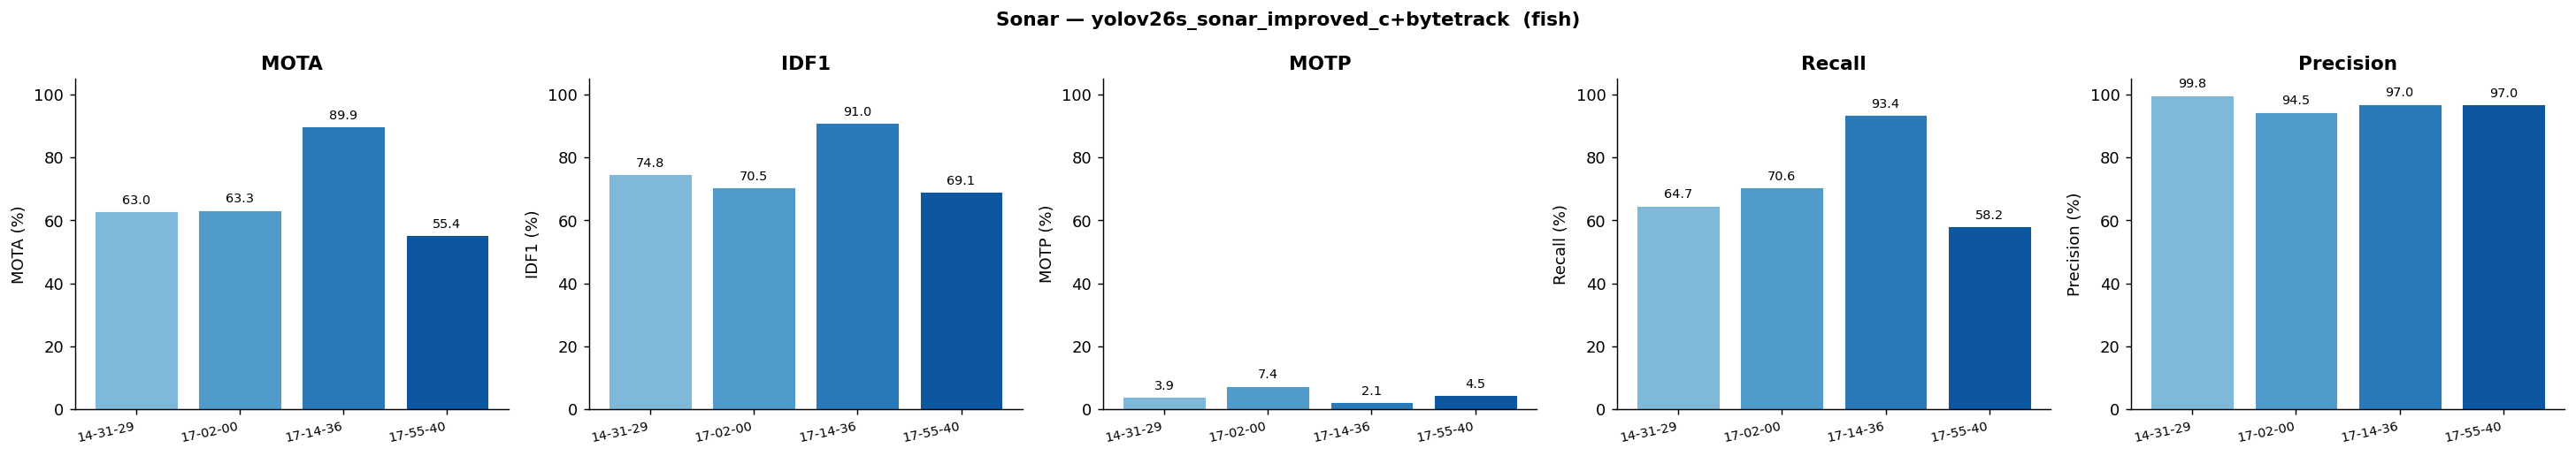

In [7]:
fig = plot_metrics_bar(results_fish,
                       metrics=("MOTA", "IDF1", "MOTP", "Recall", "Precision"),
                       title=f"Sonar — {RUN_TAG}  (fish)")
plt.savefig(f"outputs/sonar_{RUN_TAG}_fish_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 5  Metrics bar charts — net

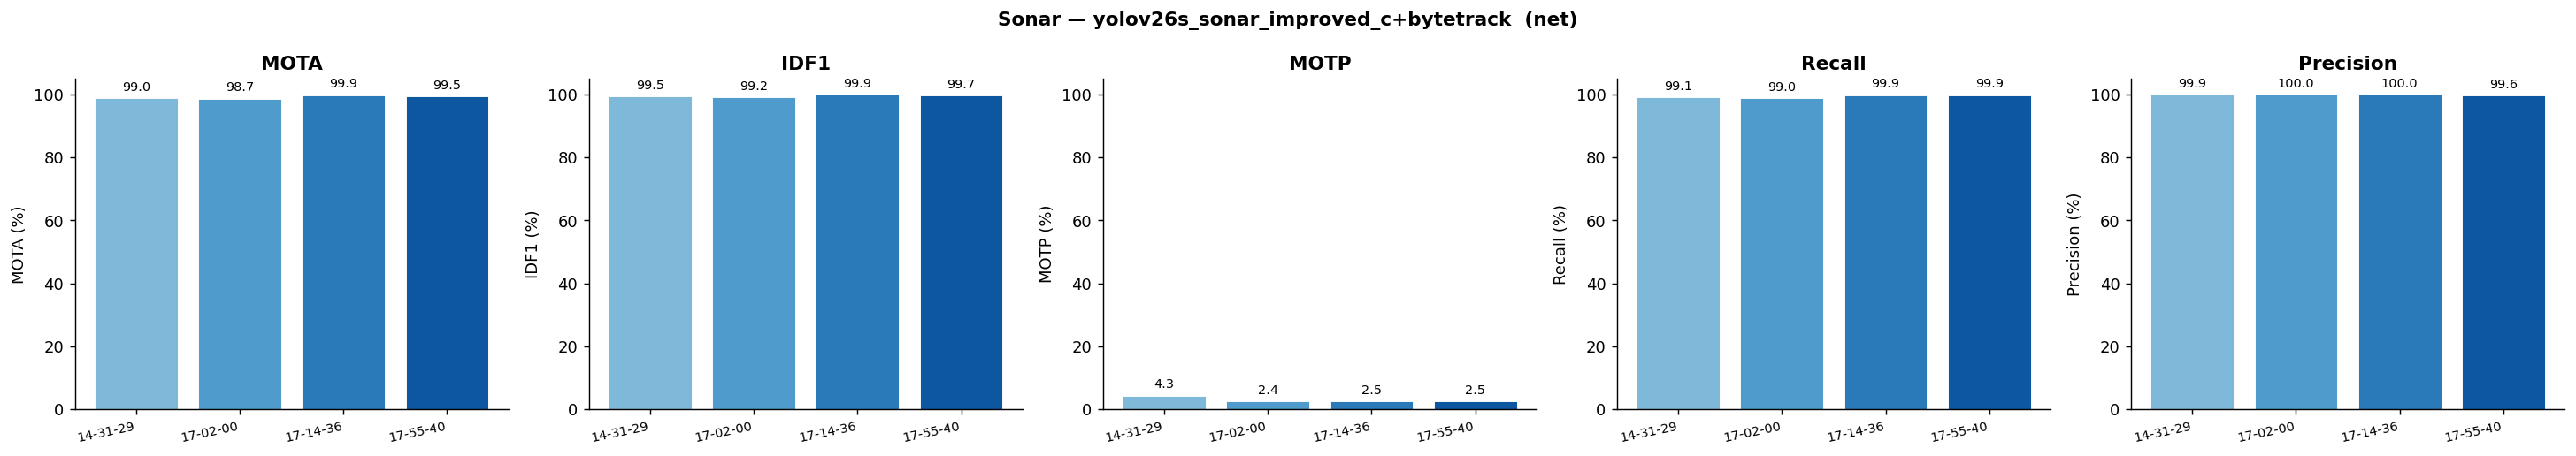

In [8]:
if results_net:
    fig = plot_metrics_bar(results_net,
                           metrics=("MOTA", "IDF1", "MOTP", "Recall", "Precision"),
                           title=f"Sonar — {RUN_TAG}  (net)")
    plt.savefig(f"outputs/sonar_{RUN_TAG}_net_metrics_bar.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No net GT found in any sequence.")

## 6  Error breakdown — fish

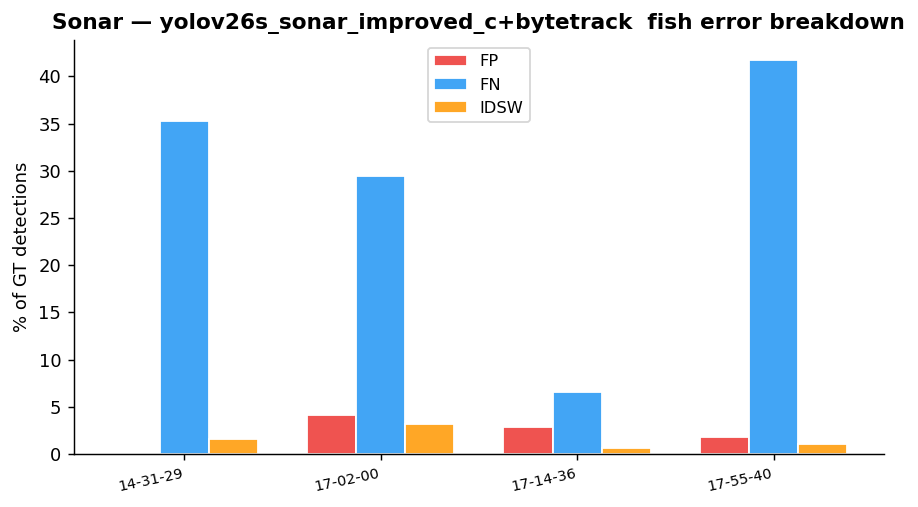

In [9]:
fig = plot_error_breakdown(results_fish, title=f"Sonar — {RUN_TAG}  fish error breakdown")
plt.savefig(f"outputs/sonar_{RUN_TAG}_fish_error_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 7  GT vs predicted track counts

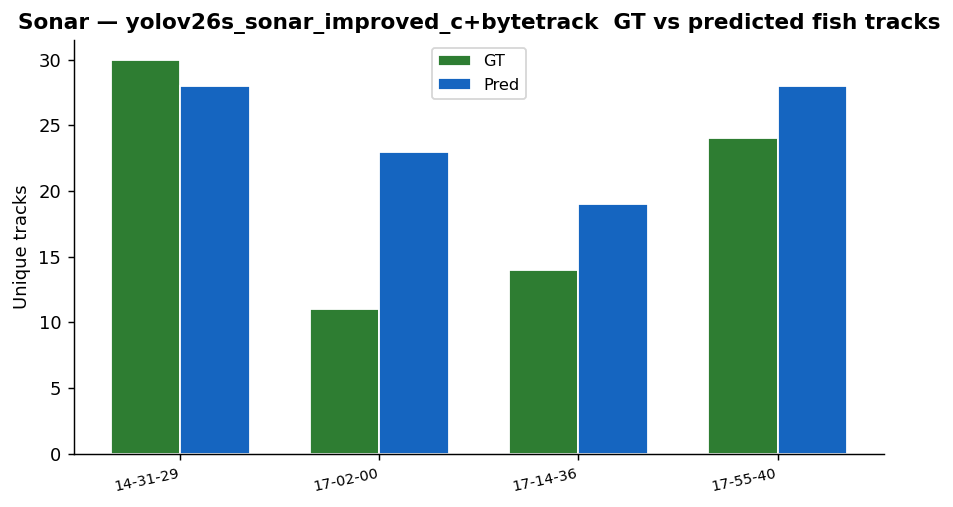

In [10]:
fig = plot_track_comparison(gt_fish, pred_fish)
plt.title(f"Sonar — {RUN_TAG}  GT vs predicted fish tracks", fontweight="bold")
plt.savefig(f"outputs/sonar_{RUN_TAG}_track_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 8  Detection count per frame — GT vs predicted

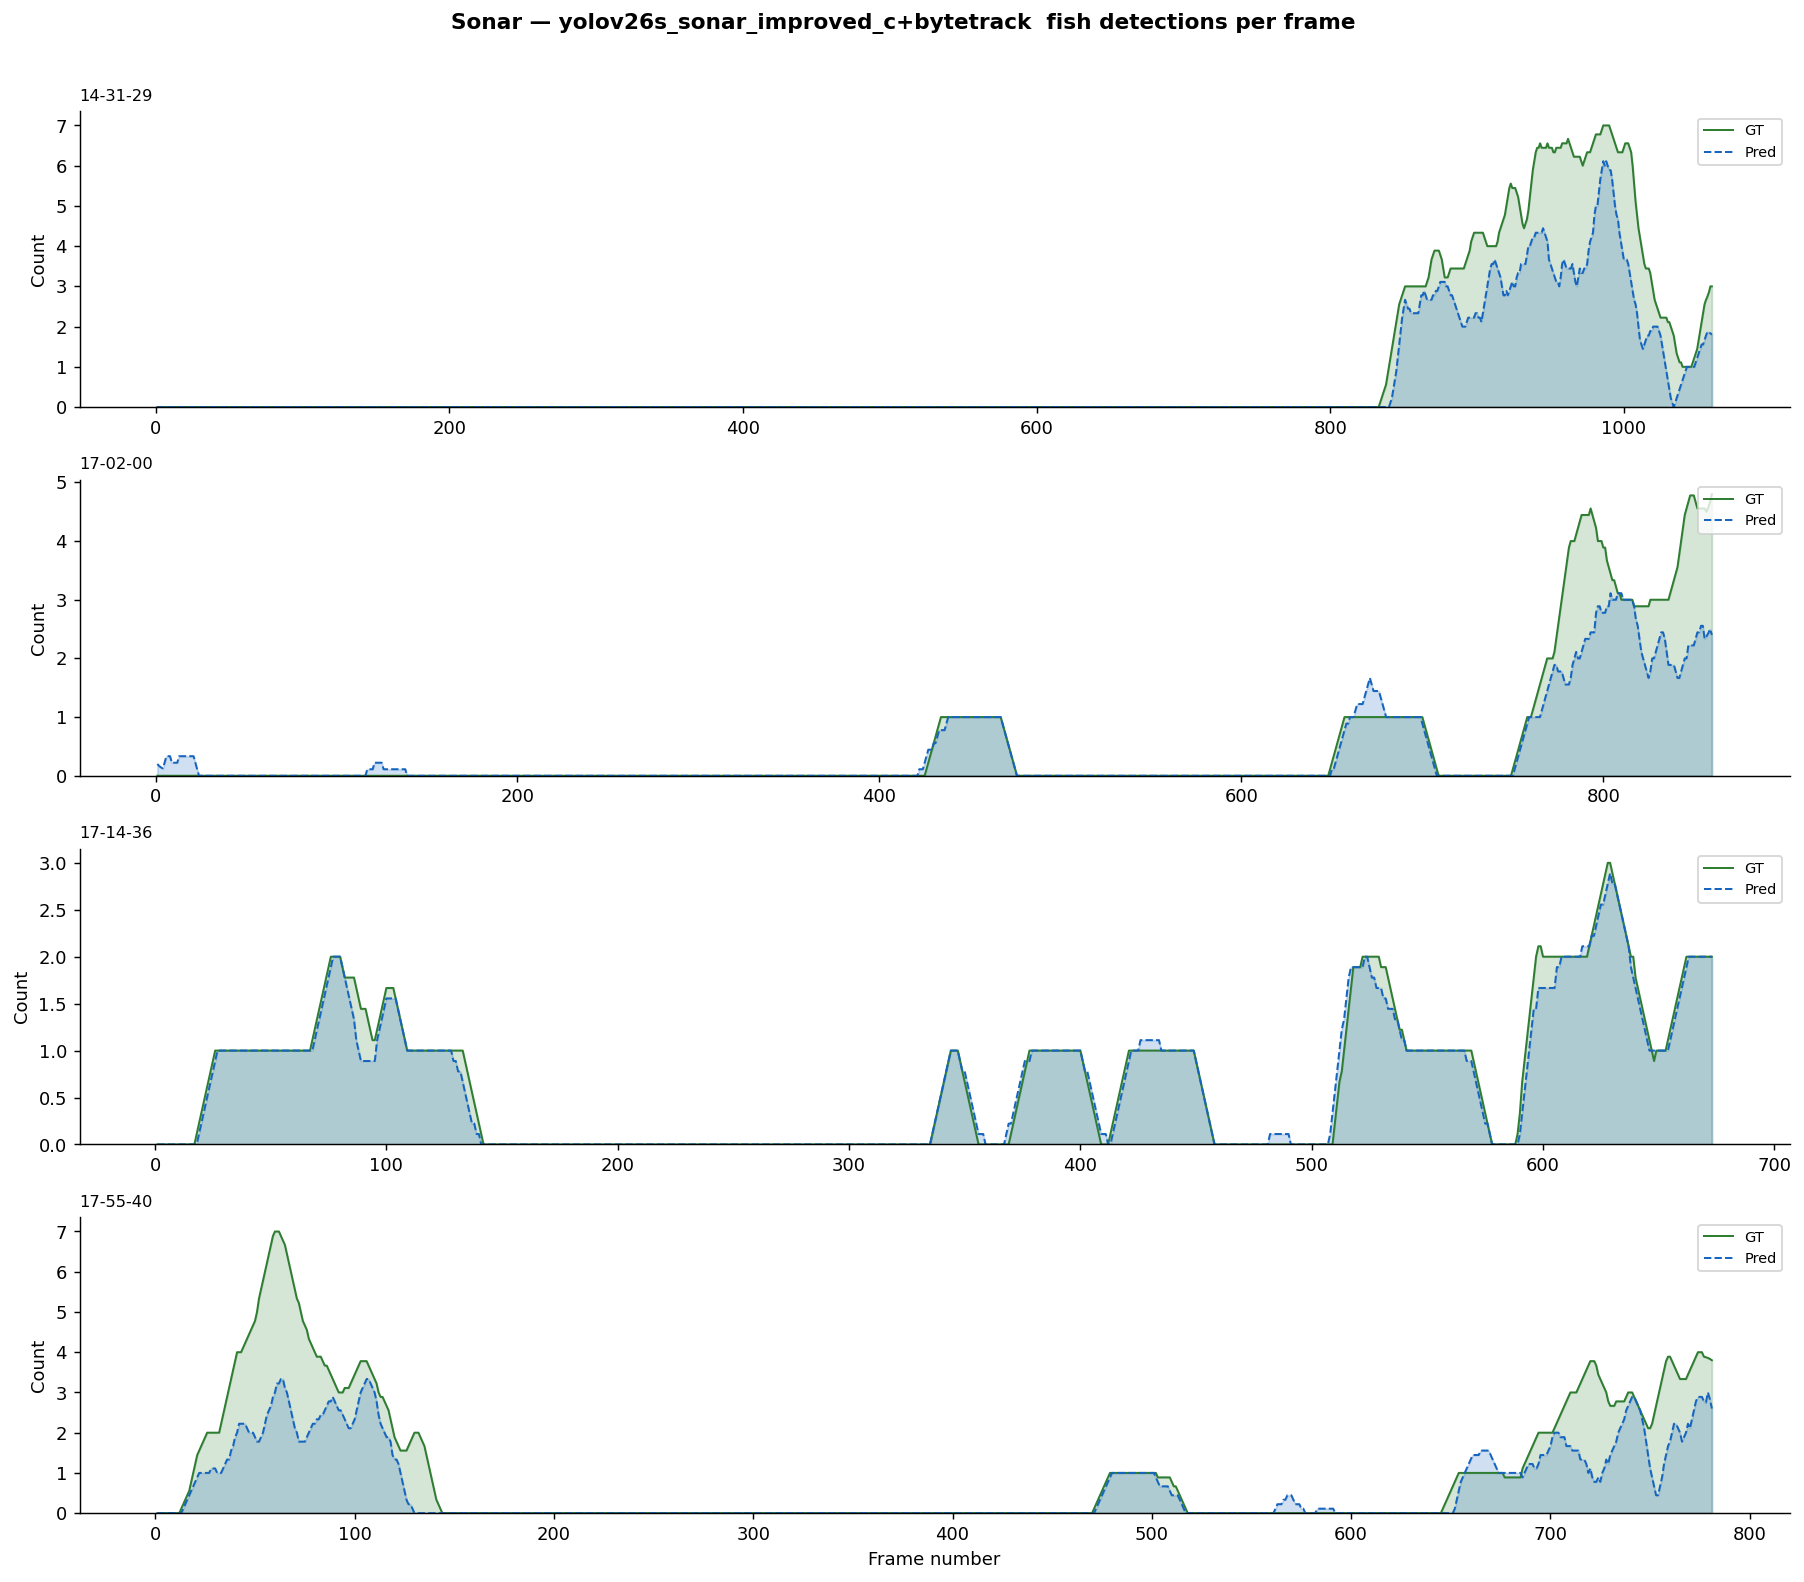

In [11]:
fig = plot_det_timeline(gt_fish, pred_fish, total_frames,
                        title=f"Sonar — {RUN_TAG}  fish detections per frame")
plt.savefig(f"outputs/sonar_{RUN_TAG}_det_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 9  Cumulative ID switches — fish

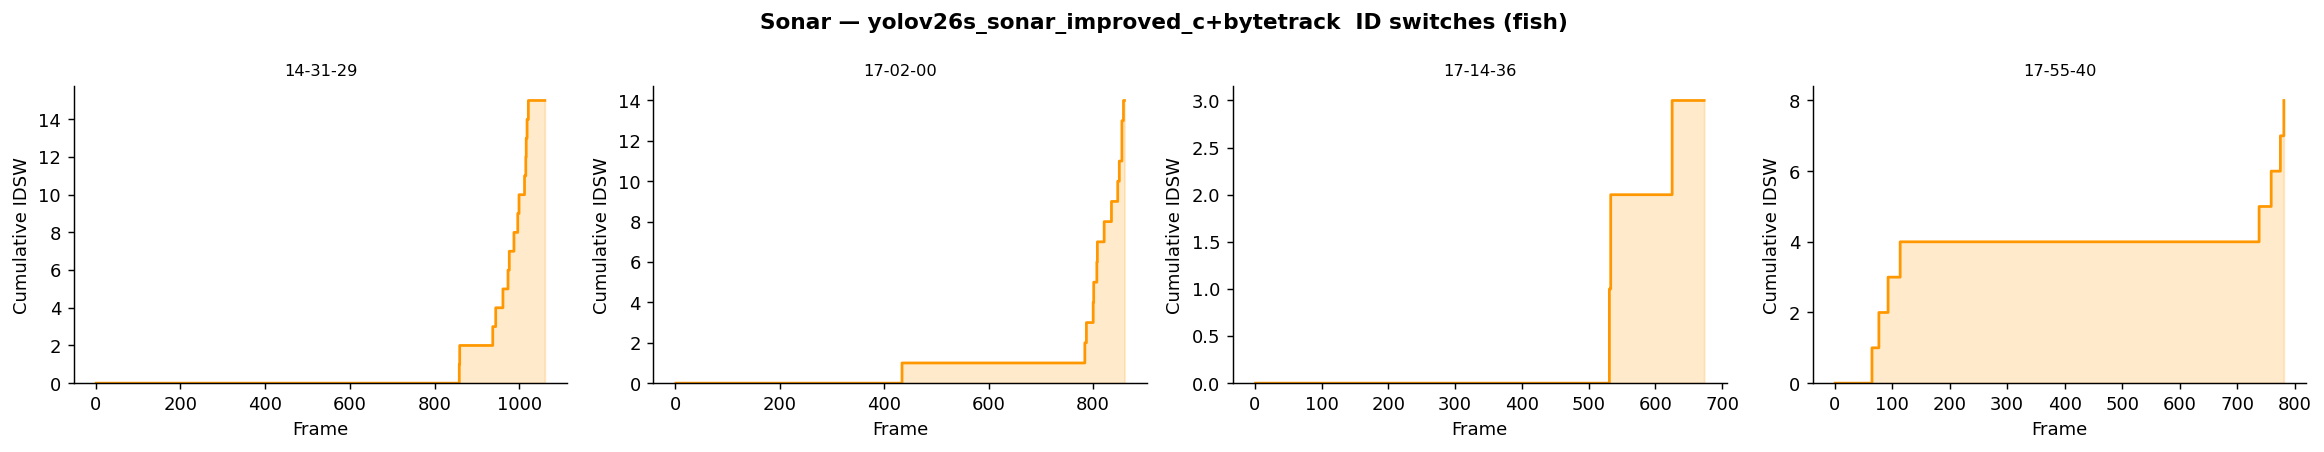

In [12]:
fig = plot_id_switches(accs_fish, total_frames,
                       title=f"Sonar — {RUN_TAG}  ID switches (fish)")
plt.savefig(f"outputs/sonar_{RUN_TAG}_id_switches.png", dpi=150, bbox_inches="tight")
plt.show()

## 10  Net range error (sonar physical space)
Compare predicted vs GT net bounding box centre range (metres from sonar).

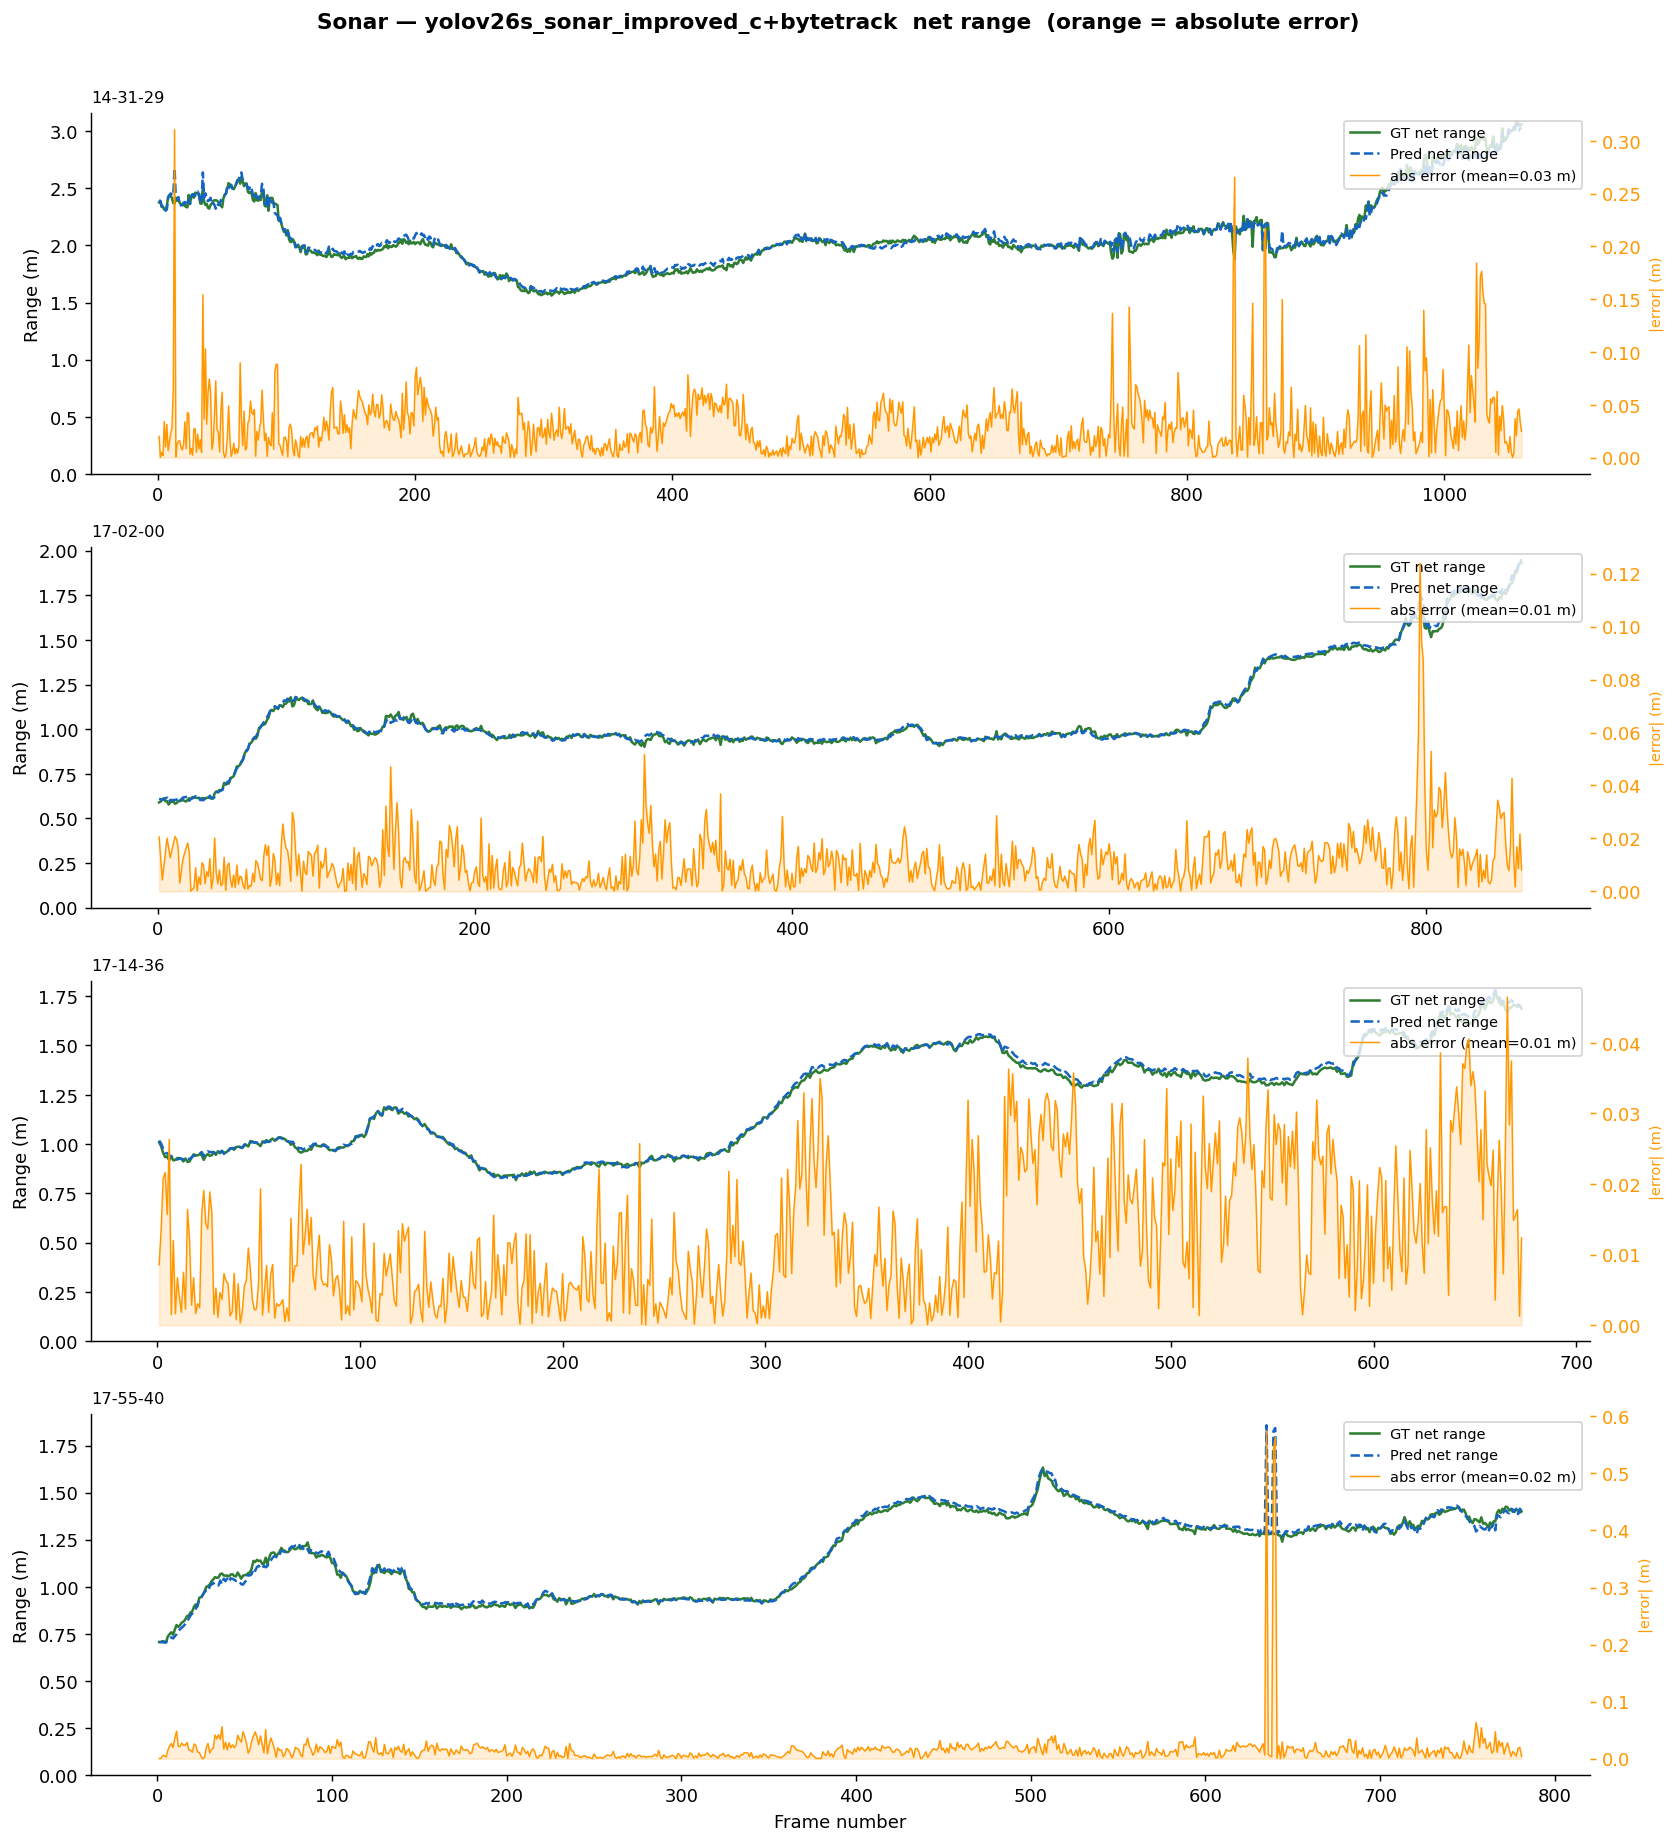

In [13]:
def add_range_m(df):
    cx = df["x"] + df["w"] / 2
    cy = df["y"] + df["h"] / 2
    _, _, rng = sonar_px_to_m(cx, cy)
    df = df.copy()
    df["range_m"] = rng
    return df

fig, axes = plt.subplots(len(SEQUENCES), 1, figsize=(13, 3.5 * len(SEQUENCES)))
if len(SEQUENCES) == 1:
    axes = [axes]

for ax, seq in zip(axes, SEQUENCES):
    gn = add_range_m(gt_net.get(seq, pd.DataFrame()))
    pn = add_range_m(pred_net.get(seq, pd.DataFrame()))

    if gn.empty:
        ax.set_title(f"{seq[-8:]} — no net GT", fontsize=9)
        continue

    gt_r  = gn.groupby("frame_norm")["range_m"].median()
    ax.plot(gt_r.index,  gt_r.values,  lw=1.4, color="#2E7D32", label="GT net range")

    if not pn.empty:
        pr_r = pn.groupby("frame_norm")["range_m"].median()
        ax.plot(pr_r.index, pr_r.values, lw=1.4, color="#1565C0",
                ls="--", label="Pred net range")

        # Error per frame (where both exist)
        merged = gt_r.rename("gt").to_frame().join(pr_r.rename("pr"), how="inner")
        err = (merged["pr"] - merged["gt"]).abs()
        ax2 = ax.twinx()
        ax2.fill_between(err.index, err.values, alpha=0.15, color="#FF9800")
        ax2.plot(err.index, err.values, lw=0.8, color="#FF9800", label=f"abs error (mean={err.mean():.2f} m)")
        ax2.set_ylabel("|error| (m)", color="#FF9800", fontsize=8)
        ax2.tick_params(axis="y", colors="#FF9800")
        ax2.spines[["top", "bottom", "left"]].set_visible(False)
        h2, l2 = ax2.get_legend_handles_labels()
    else:
        h2, l2 = [], []

    ax.set_ylabel("Range (m)")
    ax.set_title(seq[-8:], fontsize=9, loc="left")
    ax.set_ylim(bottom=0)
    h1, l1 = ax.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")

axes[-1].set_xlabel("Frame number")
fig.suptitle(f"Sonar — {RUN_TAG}  net range  (orange = absolute error)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"outputs/sonar_{RUN_TAG}_net_range_error.png", dpi=150, bbox_inches="tight")
plt.show()

## 11  MT / PT / ML breakdown — fish

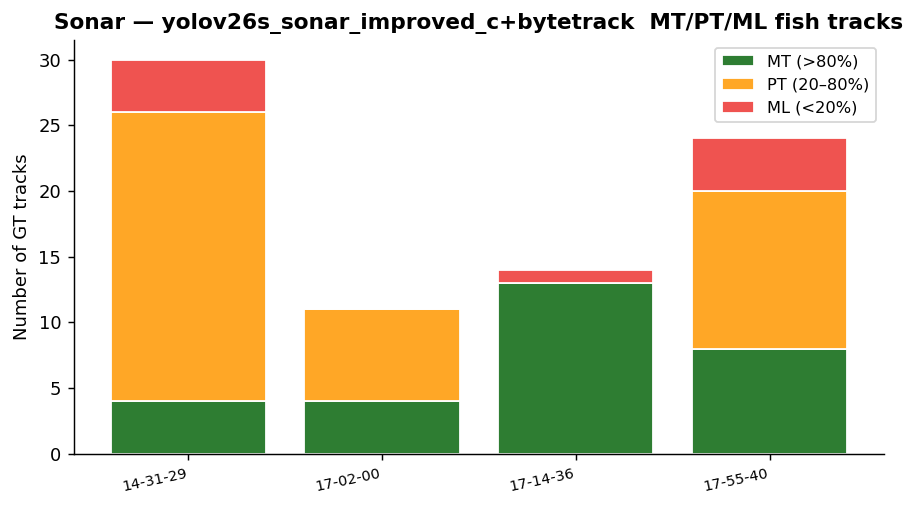

In [14]:
seq_names = list(results_fish.keys())
mt_vals = [int(results_fish[s]["mostly_tracked"].iloc[0])   for s in seq_names]
pt_vals = [int(results_fish[s]["partially_tracked"].iloc[0]) for s in seq_names]
ml_vals = [int(results_fish[s]["mostly_lost"].iloc[0])       for s in seq_names]

x = np.arange(len(seq_names))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x, mt_vals, label="MT (>80%)",  color="#2E7D32", edgecolor="white")
ax.bar(x, pt_vals, bottom=mt_vals, label="PT (20–80%)", color="#FFA726", edgecolor="white")
ax.bar(x, ml_vals, bottom=[m+p for m,p in zip(mt_vals,pt_vals)],
       label="ML (<20%)", color="#EF5350", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([s[-8:] for s in seq_names], rotation=12, ha="right", fontsize=8)
ax.set_ylabel("Number of GT tracks")
ax.set_title(f"Sonar — {RUN_TAG}  MT/PT/ML fish tracks", fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"outputs/sonar_{RUN_TAG}_mt_pt_ml.png", dpi=150, bbox_inches="tight")
plt.show()

## V2  GT vs inference frame comparison
Green = ground truth boxes, red = predicted boxes.  
Set `COMPARE_CLASS` to 1 (fish) or 2 (net).

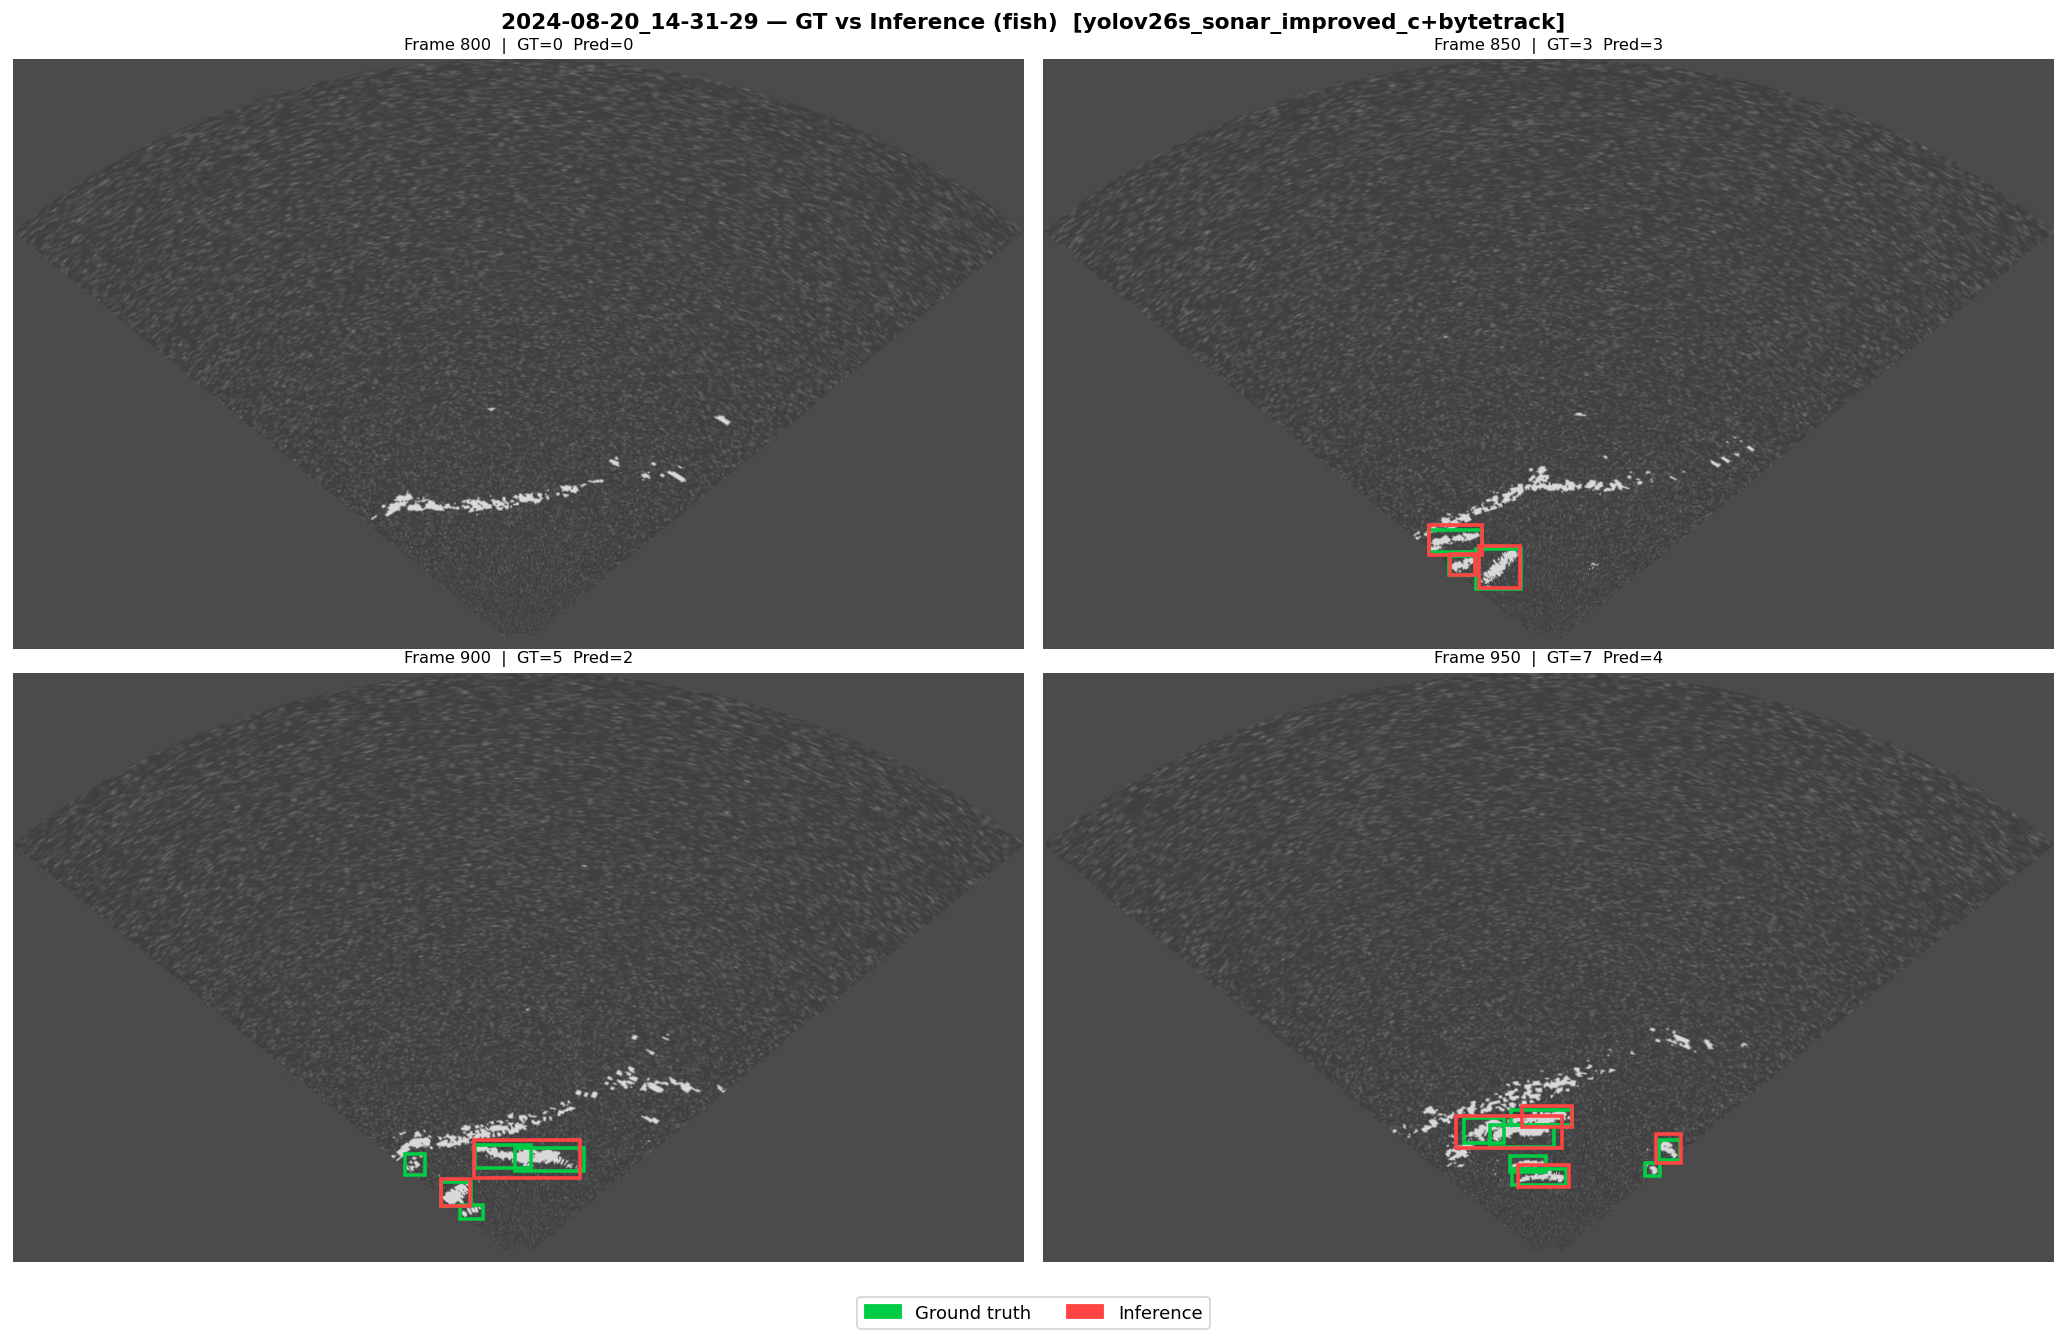

In [17]:
# ── Config ────────────────────────────────────────────────────────────────────
COMPARE_SEQ    = SEQUENCES[0]
COMPARE_FRAMES = [800, 850, 900, 950]   # frame_norm indices (1-indexed sequential)
COMPARE_CLASS  = 1                     # 1 = fish, 2 = net
NCOLS          = 2

GT_COLOR   = "#00CC44"   # green
PRED_COLOR = "#FF4444"   # red

# ── Plot ──────────────────────────────────────────────────────────────────────
idir_c      = img_dir_for(SONAR_ROOT / COMPARE_SEQ, "sonar")
fn_to_img_c = {i + 1: p for i, p in enumerate(collect_images(idir_c))}
gt_c        = gt_all[COMPARE_SEQ][gt_all[COMPARE_SEQ]["class_id"] == COMPARE_CLASS]
pred_c      = pred_all[COMPARE_SEQ][pred_all[COMPARE_SEQ]["class_id"] == COMPARE_CLASS]

valid_frames = [fn for fn in COMPARE_FRAMES if fn in fn_to_img_c]
nrows = (len(valid_frames) + NCOLS - 1) // NCOLS
fig, axes = plt.subplots(nrows, NCOLS, figsize=(NCOLS * 8, nrows * 5))
axes = np.array(axes).flatten()

for i, fn in enumerate(valid_frames):
    ax = axes[i]
    img_rgb = cv2.cvtColor(cv2.imread(str(fn_to_img_c[fn])), cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    for _, row in gt_c[gt_c["frame_norm"] == fn].iterrows():
        ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                                   linewidth=2, edgecolor=GT_COLOR, facecolor="none"))

    for _, row in pred_c[pred_c["frame_norm"] == fn].iterrows():
        ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                                   linewidth=2, edgecolor=PRED_COLOR, facecolor="none"))

    n_gt   = (gt_c["frame_norm"]   == fn).sum()
    n_pred = (pred_c["frame_norm"] == fn).sum()
    ax.set_title(f"Frame {fn}  |  GT={n_gt}  Pred={n_pred}", fontsize=9)
    ax.axis("off")

for j in range(len(valid_frames), len(axes)):
    axes[j].set_visible(False)

class_label = {1: "fish", 2: "net"}.get(COMPARE_CLASS, str(COMPARE_CLASS))
fig.legend(
    handles=[
        mpatches.Patch(color=GT_COLOR,   label="Ground truth"),
        mpatches.Patch(color=PRED_COLOR, label="Inference"),
    ],
    loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.04),
)
fig.suptitle(f"{COMPARE_SEQ} — GT vs Inference ({class_label})  [{RUN_TAG}]",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"outputs/sonar_{RUN_TAG}_gt_vs_pred_{class_label}.png", dpi=150, bbox_inches="tight")
plt.show()


## Combined — all sequences
Aggregates all selected sequences into a single evaluation.
Frame and track IDs are offset per sequence to avoid collisions.

Fish combined (4 seq)  HOTA=58.4%  MOTA=65.5%  IDF1=75.7%  IDSW=40

Run: yolov26s_sonar_improved_c+bytetrack  (fish)


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,55.7%,42.8%,86.1%,63.0%,74.8%,3.9%,64.7%,99.8%,1,334,15,4,4,30
1,17-02-00,55.9%,47.8%,73.6%,63.3%,70.5%,7.4%,70.6%,94.5%,18,130,14,4,0,11
2,17-14-36,74.1%,72.4%,87.2%,89.9%,91.0%,2.1%,93.4%,97.0%,13,30,3,13,1,14
3,17-55-40,52.4%,37.5%,81.5%,55.4%,69.1%,4.5%,58.2%,97.0%,14,326,8,8,4,24
4,COMBINED,58.4%,47.0%,83.6%,65.5%,75.7%,4.2%,68.8%,97.5%,46,820,40,29,9,79


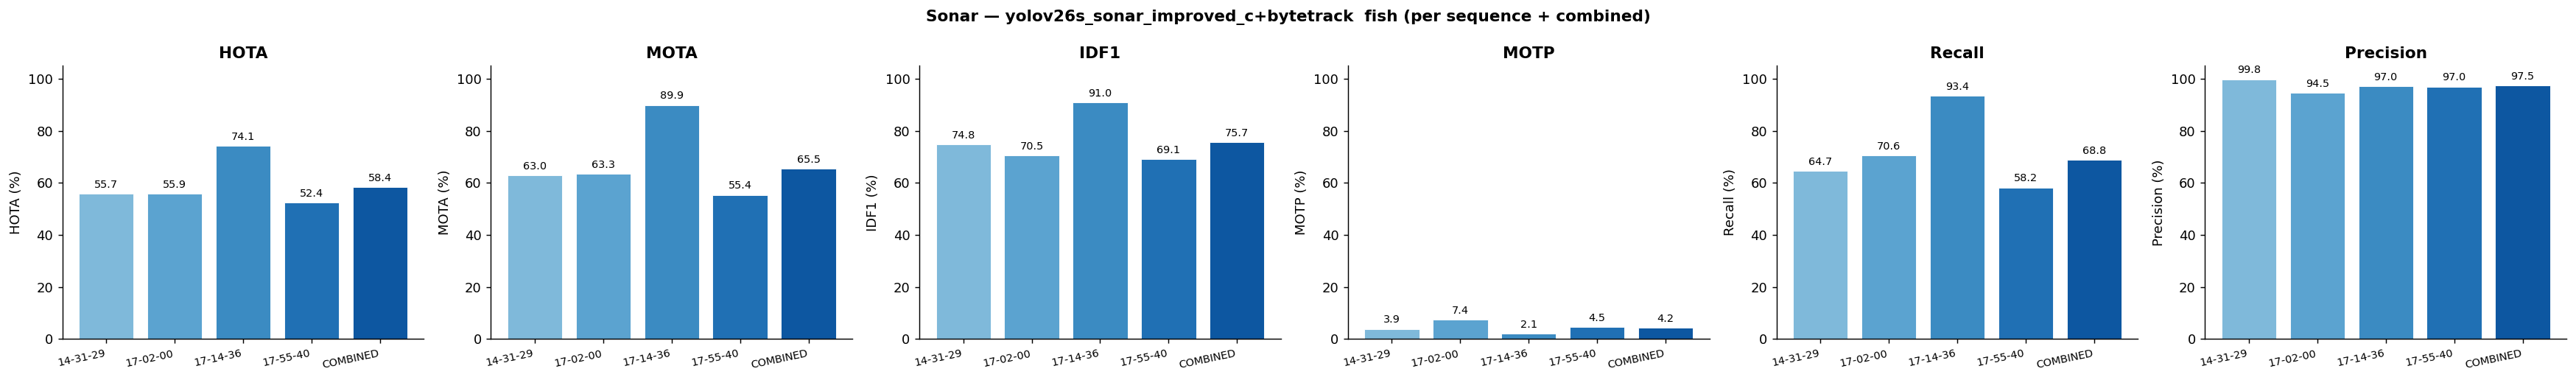

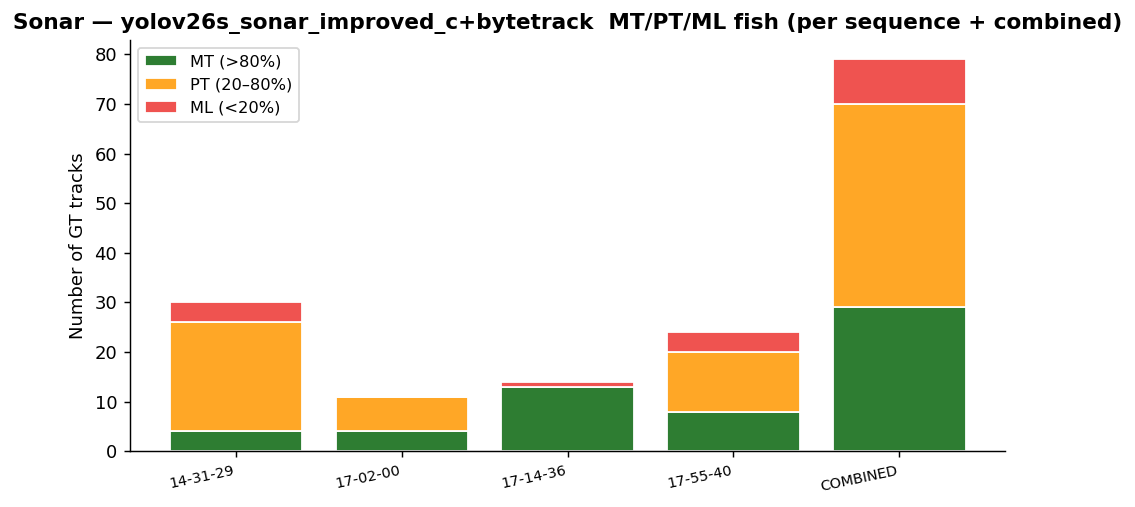

Net combined (4 seq)  HOTA=71.5%  MOTA=99.2%  IDF1=99.6%  IDSW=2

Run: yolov26s_sonar_improved_c+bytetrack  (net)


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,79.0%,71.8%,100.0%,99.0%,99.5%,4.3%,99.1%,99.9%,1,10,0,1,0,1
1,17-02-00,69.4%,61.7%,94.4%,98.7%,99.2%,2.4%,99.0%,100.0%,0,9,2,1,0,1
2,17-14-36,66.9%,58.7%,94.7%,99.9%,99.9%,2.5%,99.9%,100.0%,0,1,0,1,0,1
3,17-55-40,66.5%,58.4%,94.7%,99.5%,99.7%,2.5%,99.9%,99.6%,3,1,0,1,0,1
4,COMBINED,71.5%,62.8%,99.9%,99.2%,99.6%,3.0%,99.4%,99.9%,4,21,2,4,0,4


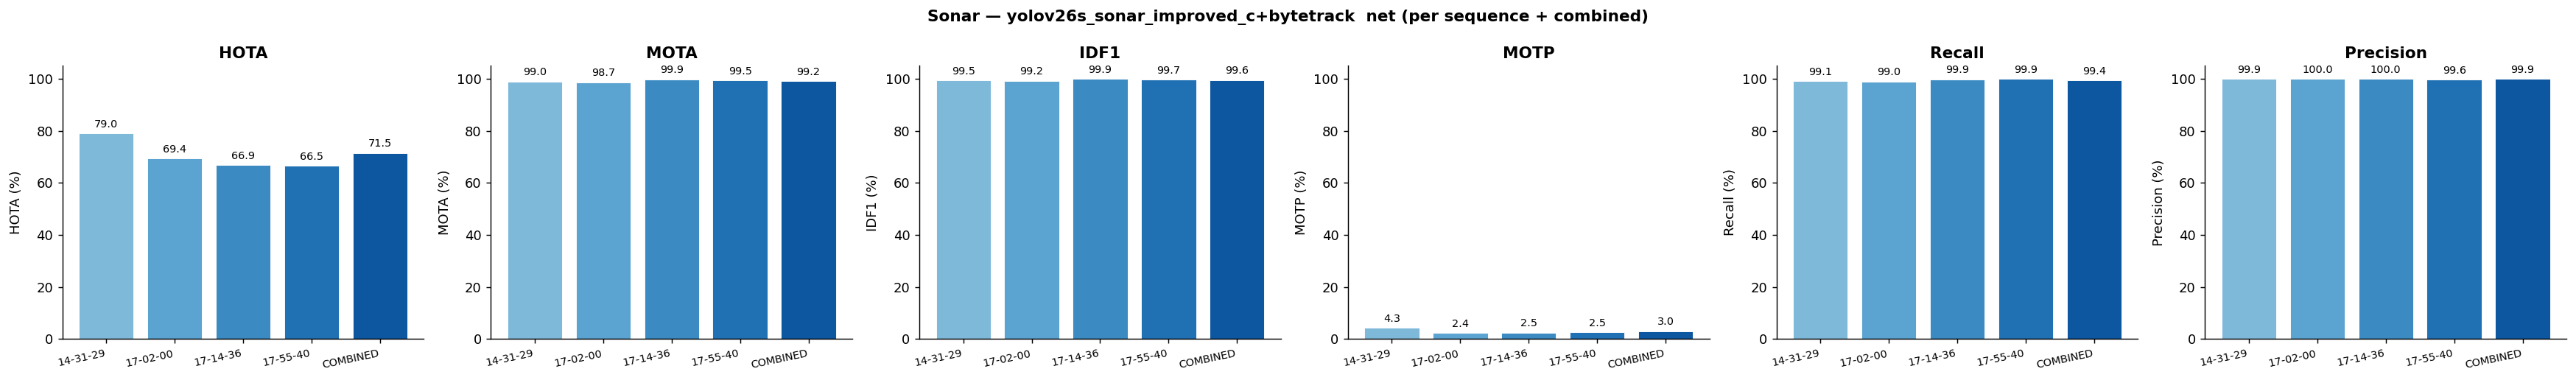

In [16]:
# ── Stack all sequences (offset frame/track IDs per sequence) ─────────────────
_OFF = 10_000

def _stack(dfs_dict):
    frames = []
    for i, (seq, df) in enumerate(dfs_dict.items()):
        if df.empty:
            continue
        frames.append(df.assign(frame_norm=df["frame_norm"] + i * _OFF,
                                track_id  =df["track_id"]   + i * _OFF))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

gt_fish_comb   = _stack(gt_fish)
pred_fish_comb = _stack(pred_fish)

# ── Combined fish metrics ──────────────────────────────────────────────────────
_, summ_fish_comb = compute_metrics(gt_fish_comb, pred_fish_comb, iou_threshold=IOU_MATCH)
hota_fish_comb    = compute_hota(gt_fish_comb, pred_fish_comb)
for k, v in hota_fish_comb.items():
    summ_fish_comb[k] = v

print(f"Fish combined ({len(SEQUENCES)} seq)  "
      f"HOTA={hota_fish_comb['hota']*100:.1f}%  "
      f"MOTA={float(summ_fish_comb['mota'].iloc[0])*100:.1f}%  "
      f"IDF1={float(summ_fish_comb['idf1'].iloc[0])*100:.1f}%  "
      f"IDSW={int(summ_fish_comb['num_switches'].iloc[0])}")

results_fish_all = dict(results_fish) | {"COMBINED": summ_fish_comb}
print(f"\nRun: {RUN_TAG}  (fish)")
display(build_summary_table(results_fish_all))

fig = plot_metrics_bar(
    results_fish_all,
    metrics=("HOTA", "MOTA", "IDF1", "MOTP", "Recall", "Precision"),
    title=f"Sonar — {RUN_TAG}  fish (per sequence + combined)",
)
plt.savefig(f"outputs/sonar_{RUN_TAG}_fish_combined_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()

_seq_all = list(results_fish_all.keys())
_mt = [int(results_fish_all[s]["mostly_tracked"].iloc[0])   for s in _seq_all]
_pt = [int(results_fish_all[s]["partially_tracked"].iloc[0]) for s in _seq_all]
_ml = [int(results_fish_all[s]["mostly_lost"].iloc[0])       for s in _seq_all]

x = np.arange(len(_seq_all))
fig, ax = plt.subplots(figsize=(max(7, len(_seq_all) * 1.5), 4))
ax.bar(x, _mt, label="MT (>80%)",  color="#2E7D32", edgecolor="white")
ax.bar(x, _pt, bottom=_mt, label="PT (20–80%)", color="#FFA726", edgecolor="white")
ax.bar(x, _ml, bottom=[m + p for m, p in zip(_mt, _pt)],
       label="ML (<20%)", color="#EF5350", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([s[-8:] for s in _seq_all], rotation=12, ha="right", fontsize=8)
ax.set_ylabel("Number of GT tracks")
ax.set_title(f"Sonar — {RUN_TAG}  MT/PT/ML fish (per sequence + combined)", fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"outputs/sonar_{RUN_TAG}_fish_combined_mt_pt_ml.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Combined net metrics (if any GT exists) ────────────────────────────────────
gt_net_comb   = _stack(gt_net)
pred_net_comb = _stack(pred_net)

if not gt_net_comb.empty:
    _, summ_net_comb = compute_metrics(gt_net_comb, pred_net_comb, iou_threshold=IOU_MATCH)
    hota_net_comb    = compute_hota(gt_net_comb, pred_net_comb)
    for k, v in hota_net_comb.items():
        summ_net_comb[k] = v

    print(f"Net combined ({len(SEQUENCES)} seq)  "
          f"HOTA={hota_net_comb['hota']*100:.1f}%  "
          f"MOTA={float(summ_net_comb['mota'].iloc[0])*100:.1f}%  "
          f"IDF1={float(summ_net_comb['idf1'].iloc[0])*100:.1f}%  "
          f"IDSW={int(summ_net_comb['num_switches'].iloc[0])}")

    results_net_all = {s: v for s, v in results_net.items()} | {"COMBINED": summ_net_comb}
    print(f"\nRun: {RUN_TAG}  (net)")
    display(build_summary_table(results_net_all))

    fig = plot_metrics_bar(
        results_net_all,
        metrics=("HOTA", "MOTA", "IDF1", "MOTP", "Recall", "Precision"),
        title=f"Sonar — {RUN_TAG}  net (per sequence + combined)",
    )
    plt.savefig(f"outputs/sonar_{RUN_TAG}_net_combined_metrics_bar.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No net GT found — skipping net combined metrics.")
